In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
def linear_regression_boston():
    # Load Boston Housing from OpenML as a dataframe
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    df = boston.frame

    # Single-feature regression: LSTAT -> MEDV
    X = df[['LSTAT']].astype(float)
    y = df['MEDV'].astype(float)

    # Hold out 20% data for evaluation
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Sort values so the regression line is drawn smoothly
    sort_idx = np.argsort(X_test['LSTAT'].values)
    X_test_sorted = X_test['LSTAT'].values[sort_idx]
    y_pred_sorted = y_pred[sort_idx]

    plt.figure(figsize=(10, 6))
    plt.scatter(X_test['LSTAT'], y_test, color='blue', alpha=0.7, label='Actual')
    plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Predicted')
    plt.xlabel('LSTAT (% lower status of population)')
    plt.ylabel('MEDV (Median value of homes in $1000s)')
    plt.title('Linear Regression - Boston Housing Dataset')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print('Linear Regression - Boston Housing Dataset')
    print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
    print('R^2 Score:', r2_score(y_test, y_pred))

In [4]:
def polynomial_regression_auto_mpg():
    # Auto MPG dataset from UCI repository
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
    column_names = [
        'mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
        'acceleration', 'model_year', 'origin', 'car_name'
    ]
    data = pd.read_csv(url, sep='\s+', names=column_names, na_values='?')
    data = data.dropna()

    # Predict fuel efficiency (mpg) using engine displacement
    X = data[['displacement']].values
    y = data['mpg'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Polynomial regression pipeline: feature expansion + scaling + linear model
    poly_model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    poly_model.fit(X_train, y_train)
    y_pred = poly_model.predict(X_test)

    # Sort x-values to draw a smooth predicted curve
    sort_idx = np.argsort(X_test[:, 0])
    X_test_sorted = X_test[sort_idx]
    y_pred_sorted = y_pred[sort_idx]

    plt.figure(figsize=(10, 6))
    plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.7, label='Actual')
    plt.plot(X_test_sorted[:, 0], y_pred_sorted, color='red', linewidth=2, label='Predicted')
    plt.xlabel('Displacement')
    plt.ylabel('Miles per gallon (mpg)')
    plt.title('Polynomial Regression - Auto MPG Dataset')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print('Polynomial Regression - Auto MPG Dataset')
    print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
    print('R^2 Score:', r2_score(y_test, y_pred))

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1999/878317125.py:8: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(url, sep='\s+', names=column_names, na_values='?')


Demonstrating Linear Regression and Polynomial Regression



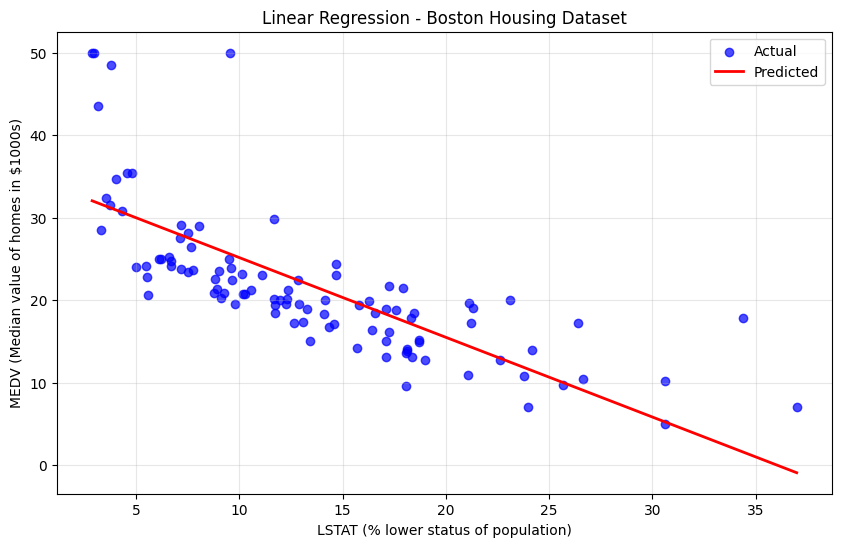

Linear Regression - Boston Housing Dataset
Mean Squared Error: 33.51954917268489
R^2 Score: 0.5429180422970384



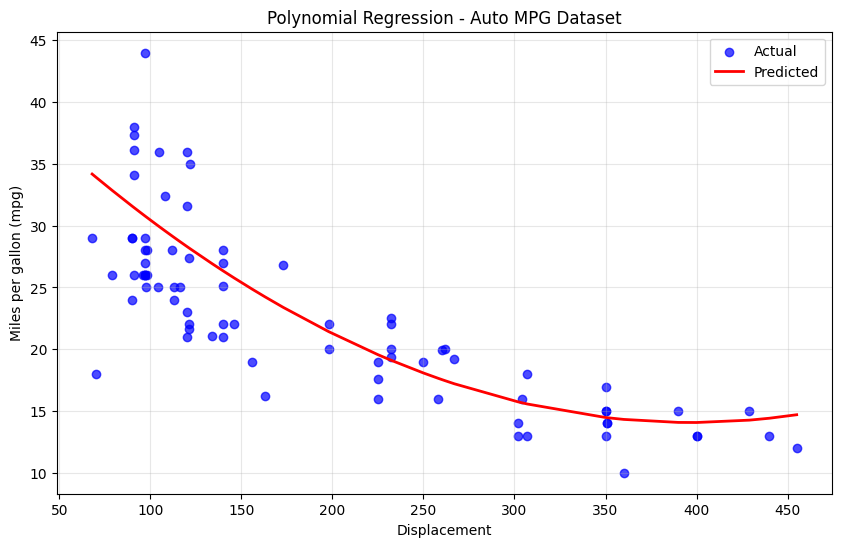

Polynomial Regression - Auto MPG Dataset
Mean Squared Error: 20.649054718308815
R^2 Score: 0.5954385038809509


In [5]:
print('Demonstrating Linear Regression and Polynomial Regression\n')
linear_regression_boston()
print()
polynomial_regression_auto_mpg()